# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [3]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [4]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
file_1 = pd.read_csv('Churn_Modelling.csv')

In [5]:
## TODO : make into a dataframe called df
df = file_1.copy()

In [6]:
## TODO : output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively

df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

## Hypothesis 1: Age

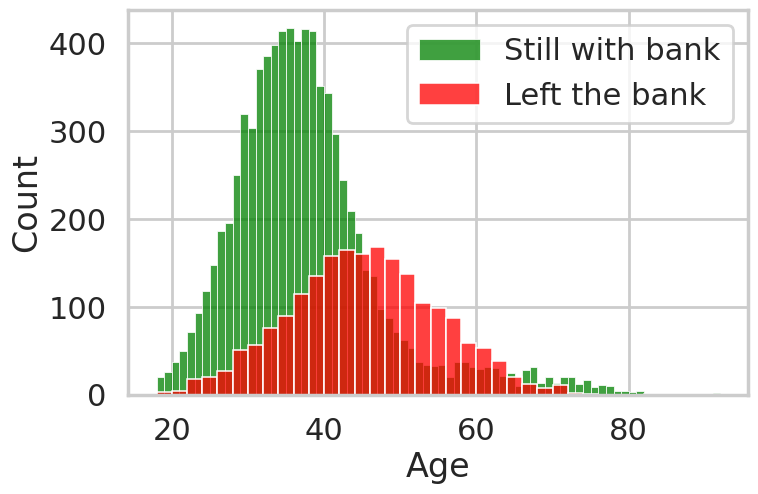

In [8]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.
sns.histplot(data=df_0, x='Age', color='green', label='Still with bank')
sns.histplot(data=df_1, x='Age', color='red', label='Left the bank')
plt.legend()
plt.show()

In [9]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
stayed_mean = df_0['Age'].mean()
stayed_std = df_0['Age'].std()

print(stayed_mean)
print(stayed_std)

37.40838879819164
10.125362911047631


In [10]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.
left_mean = df_1['Age'].mean()
left_std = df_1['Age'].std()

print(left_mean)
print(left_std)

44.8379970544919
9.761561555507132


In [12]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.
t_1,p_1 = scipy.stats.ttest_ind(df_0['Age'], df_1['Age']) # equal_var=True by default
t_1, p_1

(np.float64(-29.76681499437077), np.float64(1.2399313093427736e-186))

### Using Bootstrapping

In [14]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [15]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
diff = left_mean - stayed_mean
print("Difference in means:", diff)

# overall_mean = np.mean(np.concatenate([df_0['Age'], df_1['Age']]))
overall_mean = np.mean(df["Age"])
print("Overall mean:", overall_mean)

# shift
age_shifted_0 = df_0['Age'] - stayed_mean + overall_mean # customer who stayed
age_shifted_1 = df_1['Age'] - left_mean + overall_mean # customer who left

Difference in means: 7.429608256300263
Overall mean: 38.9218


In [16]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.
# Number of bootstrap samples
n_bootstrap = 1000

# Bootstrap standard deviation for stayed customers
bs_std_stayed = bs_choice(age_shifted_0, np.std, n_bootstrap)

# Bootstrap standard deviation for left customers
bs_std_left = bs_choice(age_shifted_1, np.std, n_bootstrap)

# Difference in standard deviations between the two groups
bs_diff_std = bs_std_stayed - bs_std_left
# print("Bootstrap standard deviation difference:", bs_diff_std)

# Since bs_diff_std is an array of 1000 bootstrap differences, we can summarize it
mean_diff_std = np.mean(bs_diff_std)
print(f"Mean Bootstrap Standard Deviation Difference: {mean_diff_std:.2f}")

Mean Bootstrap Standard Deviation Difference: 0.37


In [17]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.
# diff: observed difference
# bs_diff_std: bootstrap distribution array
p_value = np.sum(bs_diff_std >= diff) / n_bootstrap # proportion of extreme values
print("P-value:", p_value)

P-value: 0.0


### Conclusion
Do we reject the Null Hypothesis ? Why ?

## Hypothesis 2: Credit Score

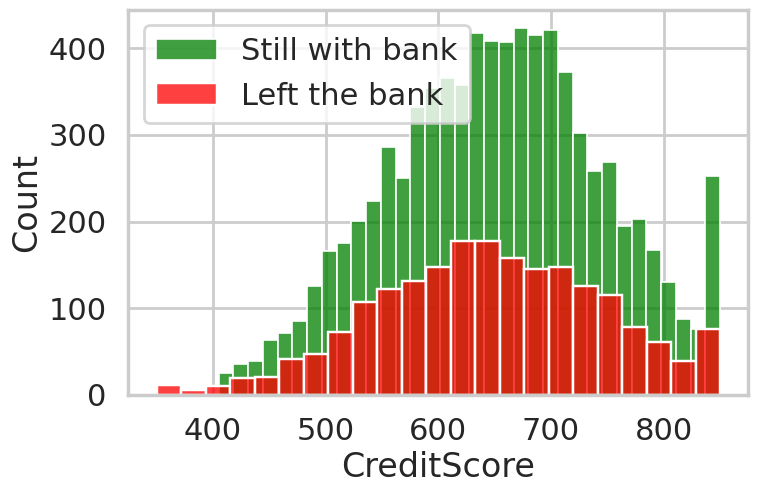

In [18]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
sns.histplot(data=df_0, x='CreditScore', color='green', label='Still with bank')
sns.histplot(data=df_1, x='CreditScore', color='red', label='Left the bank')
plt.legend()
plt.show()

In [19]:
print("Variance of CreditScore (Still with bank):", df_0["CreditScore"].var())
print("Variance of CreditScore (Left the bank):", df_1["CreditScore"].var())
variance_ratio = df_0["CreditScore"].var() / df_1["CreditScore"].var()
print("Variance Ratio:", variance_ratio)

Variance of CreditScore (Still with bank): 9149.656541843924
Variance of CreditScore (Left the bank): 10064.403893876843
Variance Ratio: 0.909110627745231


In [20]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).
# equal_var=False tells Python to not assume equal variance, making the test more robust
# but if we compute the variance ratio between Still with bnk and Left the bank
# it is 0.9 ≈ 1, which mean the variances are similar and we can use equal_var = True

t_2,p_2 = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False) # equal_var=True by default
t_2, p_2

(np.float64(2.6346605436575796), np.float64(0.008464728991832862))


### Conclusion
Do we reject the Null Hypothesis ? Why ?

## Hypothesis 3: Balance

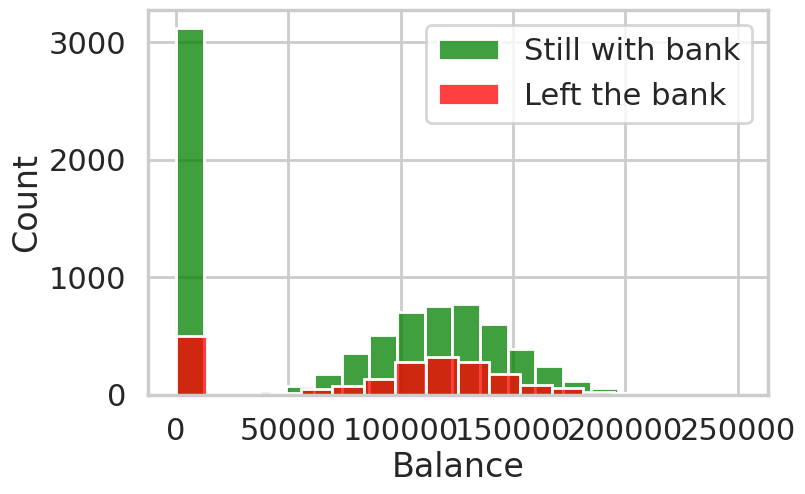

In [21]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).
sns.histplot(data=df_0, x='Balance', color='green', label='Still with bank')
sns.histplot(data=df_1, x='Balance', color='red', label='Left the bank')
plt.legend()
plt.show()

In [22]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
t_3,p_3 = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False) # equal_var=True by default
t_3, p_3

(np.float64(-12.471280320050688), np.float64(6.318663518527974e-35))

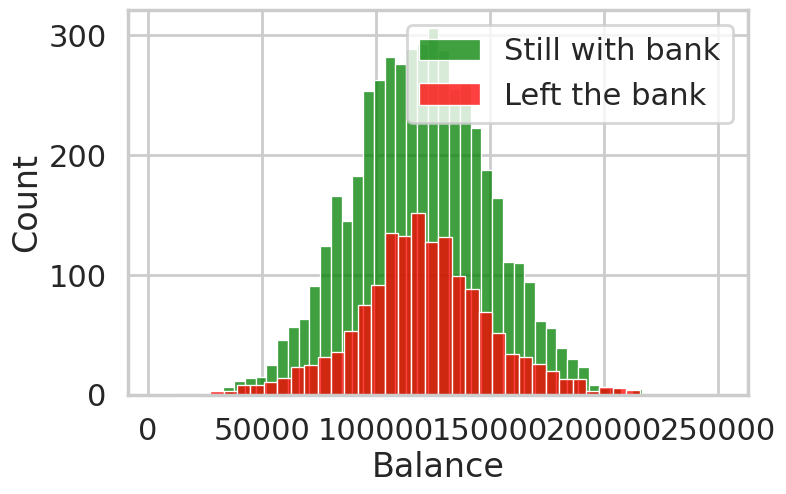

In [23]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.
sns.histplot(data=df_0[df_0['Balance'] != 0], x='Balance', color='green', label='Still with bank')
sns.histplot(data=df_1[df_1['Balance'] != 0], x='Balance', color='red', label='Left the bank')
plt.legend()
plt.show()

In [24]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.
t_4,p_4 = scipy.stats.ttest_ind(df_0[df_0['Balance'] != 0]['Balance'], df_1[df_1['Balance'] != 0]['Balance'], equal_var=False)
t_4, p_4

(np.float64(-1.3604774889985365), np.float64(0.17379960354870824))

## Conclusion

Do we reject the Null Hypothesis ? Why ?

## Hypothesis 4: Estimated Salary

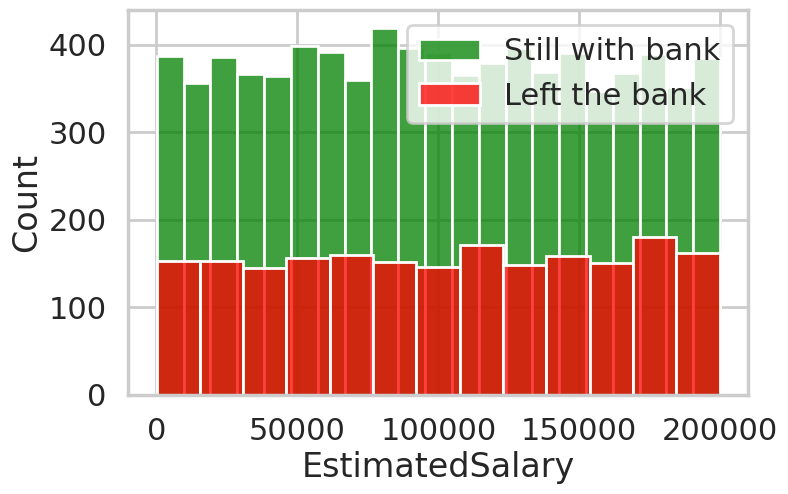

In [25]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
sns.histplot(data=df_0, x='EstimatedSalary', color='green', label='Still with bank')
sns.histplot(data=df_1, x='EstimatedSalary', color='red', label='Left the bank')
plt.legend()
plt.show()

In [26]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
t_5,p_5 = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
t_5, p_5

(np.float64(-1.2033683196586242), np.float64(0.22892461305145795))

### Using Bootstrapping

In [28]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.
diff_EstimatedSalary = df_1['EstimatedSalary'].mean() - df_0['EstimatedSalary'].mean()
print("Difference in means:", diff_EstimatedSalary)

overall_mean_es = np.mean(df["EstimatedSalary"])
print("Overall mean:", overall_mean_es)

# shift
salary_shifted_0 = df_0['EstimatedSalary'] - df_0['EstimatedSalary'].mean() + overall_mean_es # customer who stayed
salary_shifted_1 = df_1['EstimatedSalary'] - df_1['EstimatedSalary'].mean() + overall_mean_es # customer who left

Difference in means: 1727.2857587371254
Overall mean: 100090.239881


In [29]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.
# Number of bootstrap samples
n_bootstrap = 1000

# Bootstrap mean for stayed customers
bs_mean_stayed = bs_choice(salary_shifted_0, np.mean, n_bootstrap)

# Bootstrap mean for left customers
bs_mean_left = bs_choice(salary_shifted_1, np.mean, n_bootstrap)

# Difference in mean between the two groups
bs_diff_mean = bs_mean_stayed - bs_mean_left
# print("Bootstrap mean difference:", bs_diff_mean)

In [30]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.
# diff: observed difference
# bs_diff_std: bootstrap distribution array
p_value = np.sum(bs_diff_mean >= diff_EstimatedSalary) / n_bootstrap # proportion of extreme values
print("P-value:", p_value)

P-value: 0.119


### Conclusion
Do we reject the Null Hypothesis ? Why ?

* Using t-test, the probabilty of null hypothesis is p-value = 0.23 > 0.05. This means there is no statistically significant difference in salary between those who left and those who stayed. We fail to reject H0, no strong evidence that salary affects customer departure.

* Using Bootstrap, the probability of null hypothesis is p-value = 0.117 > 0.05. This confirms what we saw in the t-test.

Salary does not appear to be an important factor in customer retenion or departure.

## Final Conclusion
What will be the most helpful feature in predicting churning?

**The variables Age and CreditScore will be most helpful in predicting churning. In case we consider zero balances, the variable Balance would be significant too.**